## SQL + PYTHON INTEGRATION PROJECT
### PROJECT TITLE
### Sales Database Analysis System (Python + SQL)
#### GOAL

👉 Build a system that:
- Connects Python to database
- Stores data in SQL
- Runs queries using Python
- Shows results like a real analyst

#### WHAT YOU WILL LEARN
- Python + SQL connection
- Executing SQL queries in Python
- Reading database into Pandas
- Real-world backend logic

### TECHNOLOGY
- Python
- SQLite (database)
- Pandas

### STEP 1 — CREATE DATABASE

In [1]:
import sqlite3

# Connect to database (creates if not exists)
conn = sqlite3.connect("sales.db")
cursor = conn.cursor()

# Create tables
cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
    id INTEGER PRIMARY KEY,
    name TEXT,
    city TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS products (
    id INTEGER PRIMARY KEY,
    product_name TEXT,
    price INTEGER
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS orders (
    id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    product_id INTEGER,
    quantity INTEGER
)
""")

conn.commit()

### STEP 2 — INSERT DATA

In [2]:
# Insert sample data
cursor.execute("INSERT INTO customers VALUES (1, 'Ali', 'Lahore')")
cursor.execute("INSERT INTO customers VALUES (2, 'Sara', 'Karachi')")

cursor.execute("INSERT INTO products VALUES (1, 'Laptop', 100000)")
cursor.execute("INSERT INTO products VALUES (2, 'Mobile', 50000)")

cursor.execute("INSERT INTO orders VALUES (1, 1, 1, 1)")
cursor.execute("INSERT INTO orders VALUES (2, 2, 2, 2)")

conn.commit()

### STEP 3 — RUN SQL QUERY FROM PYTHON

In [3]:
import pandas as pd

query = """
SELECT customers.name, products.product_name, orders.quantity,
(products.price * orders.quantity) AS total
FROM orders
JOIN customers ON orders.customer_id = customers.id
JOIN products ON orders.product_id = products.id
"""

df = pd.read_sql_query(query, conn)

print(df)

   name product_name  quantity   total
0   Ali       Laptop         1  100000
1  Sara       Mobile         2  100000


### STEP 4 — ANALYSIS USING PANDAS

In [4]:
# Total revenue
print("Total Revenue:", df["total"].sum())

# Top customer
top_customer = df.groupby("name")["total"].sum().idxmax()
print("Top Customer:", top_customer)

Total Revenue: 200000
Top Customer: Ali


### STEP 5 — VISUALIZATION

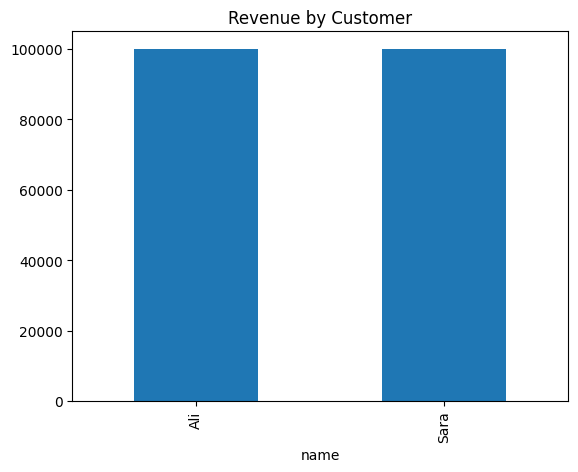

In [5]:
import matplotlib.pyplot as plt

df.groupby("name")["total"].sum().plot(kind="bar")
plt.title("Revenue by Customer")
plt.show()

### STEP 6 — CLOSE CONNECTION

In [6]:
conn.close()

### FULL PROJECT FLOW

👉 Database → SQL → Python → Pandas → Visualization

This is exactly how real systems work

### How do connect Python to database?

### Answer:

“I use libraries like sqlite3 or MySQL connector to establish a connection and execute SQL queries from Python.”

### Why combine SQL and Python?

### Answer:

“SQL handles data storage and retrieval efficiently, while Python is used for advanced analysis, automation, and visualization.”